# East River: Precipitation Elevation Gradient Evaluation

Does the PRISM/MetSim forcing show a realistic elevation gradient within the East River basin?

**Domain:** `East_River_distributed_elevAspect` — 18 HRUs, 4 elevation bands, 4–5 aspect classes  
**Forcing:** MetSim-remapped PRISM (`basin_averaged_data/`)  
**Reference:** ASO peak SWE flights (WY2018, 2019, 2022–2026) + Butte SNOTEL + Billy Barr (Gothic)

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd
from glob import glob
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
DOMAIN       = 'East_River_distributed_elevAspect'
FORCING_PATH = f'/scratch/dlhogan/ess-project-data/domain_{DOMAIN}/forcing/basin_averaged_data'
SHP_PATH     = (f'/scratch/dlhogan/ess-project-data/domain_{DOMAIN}'
                f'/shapefiles/catchment/{DOMAIN}_HRUs_elevation_aspect.shp')
ASO_DIR      = '/scratch/dlhogan/ess-project-data/geospatial-data/ASO/East'
DEM_PATH     = (f'/scratch/dlhogan/ess-project-data/domain_{DOMAIN}'
                f'/attributes/elevation/dem/domain_{DOMAIN}_elv.tif')
BILLY_NC     = '/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_20011001-20251025_30min.nc'
SNOTEL_PATH  = '/scratch/dlhogan/ess-project-data/meteorological-data/SNOTEL'

# ── HRU metadata ─────────────────────────────────────────────────────────────
shp_raw = gpd.read_file(SHP_PATH).sort_values('HRU_ID').reset_index(drop=True)
ac_col  = 'aspectClas'
hru_meta = shp_raw[['HRU_ID', 'elevClass', ac_col, 'elev_mean']].set_index('HRU_ID')

print(f'Total HRUs: {len(hru_meta)}')
for ec in sorted(hru_meta['elevClass'].unique()):
    sub = hru_meta[hru_meta['elevClass'] == ec]
    print(f'  Band {ec}: mean elev = {sub["elev_mean"].mean():.0f} m, '
          f'n_hru = {len(sub)}, '
          f'aspects = {sorted(sub[ac_col].unique())}')

Total HRUs: 18
  Band 1: mean elev = 2693 m, n_hru = 5, aspects = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Band 2: mean elev = 3008 m, n_hru = 5, aspects = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Band 3: mean elev = 3361 m, n_hru = 4, aspects = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Band 4: mean elev = 3703 m, n_hru = 4, aspects = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [2]:
# ── Load forcing: monthly ppt per HRU ─────────────────────────────────────────
import netCDF4 as nc
from pathlib import Path

files = sorted(Path(FORCING_PATH).glob('*.nc'))
print(f'Forcing files found: {len(files)}')

records = []
for f in files:
    stem = f.stem  # e.g. East_River_..._metsim_198101
    ym   = stem.split('metsim_')[-1]
    year, month = int(ym[:4]), int(ym[4:6])
    with xr.open_dataset(f) as ds:
        ppt = (ds['pptrate'] * 3600).sum(dim='time').values   # mm/month per HRU
    records.append({'year': year, 'month': month, 'ppt': ppt})

hru_ids = hru_meta.index.values
forcing_df = pd.DataFrame(
    [r['ppt'] for r in records],
    index=pd.MultiIndex.from_tuples(
        [(r['year'], r['month']) for r in records], names=['year', 'month']
    ),
    columns=hru_ids,
)

# Climatological monthly mean — wet months only (> 1 mm)
hru_clim = forcing_df.where(forcing_df > 1.0).groupby(level='month').mean()   # (12, 18)
print(f'Forcing loaded: {len(records)} months, {forcing_df.shape[1]} HRUs')
print(f'Year range: {forcing_df.index.get_level_values("year").min()}–'
      f'{forcing_df.index.get_level_values("year").max()}')

Forcing files found: 540
Forcing loaded: 540 months, 18 HRUs
Year range: 1981–2025


In [3]:
# ── Observations: Butte SNOTEL (#380) + Billy Barr (Gothic) ───────────────────
#
# Butte SNOTEL: 38.894°N, 106.953°W, 10190 ft = 3106 m  (inside East River basin)
# Billy Barr:   Gothic CO, ~2930 m  (RMBL long-term precipitation record)

STATIONS = {
    'Butte SNOTEL': (f'{SNOTEL_PATH}/380_Butte_sntl_obs.csv', 3106),
}
STATION_COLORS = {'Butte SNOTEL': '#c0392b', 'Billy Barr (Gothic)': '#27ae60'}
STATION_MARKERS = {'Butte SNOTEL': 'o', 'Billy Barr (Gothic)': 's'}

obs_clim  = {}
obs_nyears = {}

# Butte SNOTEL
df_butte = pd.read_csv(f'{SNOTEL_PATH}/380_Butte_sntl_obs.csv', parse_dates=['datetime'])
df_butte.index = pd.to_datetime(df_butte['datetime'], utc=True).dt.tz_localize(None)
df_butte = df_butte.sort_index()
ppt_butte = df_butte['PRECIPITATION'].resample('D').sum() * 25.4   # inches → mm
ppt_butte = ppt_butte[(ppt_butte >= 0) & (ppt_butte <= 250)]
mo_butte  = ppt_butte.resample('ME').sum().where(lambda x: x > 1.0)
obs_clim['Butte SNOTEL']  = mo_butte.groupby(mo_butte.index.month).mean()
obs_nyears['Butte SNOTEL'] = mo_butte.groupby(mo_butte.index.month).count().min()

# Billy Barr (Gothic CO) — 30-min NetCDF with quality flag
bb_ds = xr.open_dataset(BILLY_NC)
bb_ds = bb_ds.where((bb_ds['precip_bad_flag'] == 0) & (bb_ds['precip'] >= 0))
bb_df = bb_ds['precip'].to_dataframe().resample('D').sum()
bb_df.rename(columns={'precip': 'ppt'}, inplace=True)
bb_mo = bb_df['ppt'].resample('ME').sum().where(lambda x: x > 1.0)
obs_clim['Billy Barr (Gothic)']  = bb_mo.groupby(bb_mo.index.month).mean()
obs_nyears['Billy Barr (Gothic)'] = bb_mo.groupby(bb_mo.index.month).count().min()
STATIONS['Billy Barr (Gothic)'] = (None, 2930)   # elevation only

for name in obs_clim:
    elev = STATIONS[name][1]
    ny   = obs_nyears[name]
    total = obs_clim[name].reindex(range(1, 13)).sum()
    print(f'{name} ({elev} m, n≈{ny} yr): annual mean = {total:.0f} mm')

Butte SNOTEL (3106 m, n≈43 yr): annual mean = 779 mm
Billy Barr (Gothic) (2930 m, n≈9 yr): annual mean = 763 mm


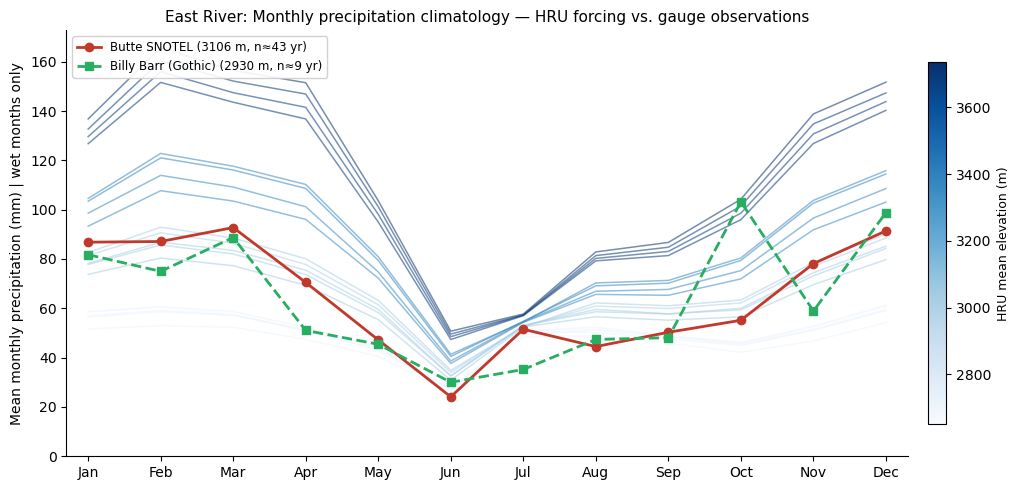

In [4]:
# ── Monthly climatology: all HRUs coloured by elevation + station obs ──────────
months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

elev_vals = hru_meta['elev_mean'].values
norm = mcolors.Normalize(vmin=elev_vals.min(), vmax=elev_vals.max())
cmap = cm.get_cmap('Blues', 256)

fig, ax = plt.subplots(figsize=(11, 5))

for hru_id in hru_ids:
    elev  = hru_meta.loc[hru_id, 'elev_mean']
    color = cmap(norm(elev))
    y     = hru_clim[hru_id].values
    ax.plot(months, y, color=color, alpha=0.55, linewidth=1.1, zorder=2)

STATION_STYLES = {
    'Butte SNOTEL':       dict(ls='-',  marker='o', ms=6),
    'Billy Barr (Gothic)': dict(ls='--', marker='s', ms=6),
}
for name, clim in obs_clim.items():
    elev = STATIONS[name][1]
    ny   = obs_nyears[name]
    ax.plot(months, clim.reindex(months).values,
            color=STATION_COLORS[name], linewidth=2.0, zorder=5,
            label=f'{name} ({elev} m, n≈{ny} yr)',
            **STATION_STYLES[name])

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.85)
cb.set_label('HRU mean elevation (m)', fontsize=9)

ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Mean monthly precipitation (mm) | wet months only', fontsize=10)
ax.set_title('East River: Monthly precipitation climatology — HRU forcing vs. gauge observations', fontsize=11)
ax.legend(fontsize=8.5, framealpha=0.9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0.7, 12.3)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

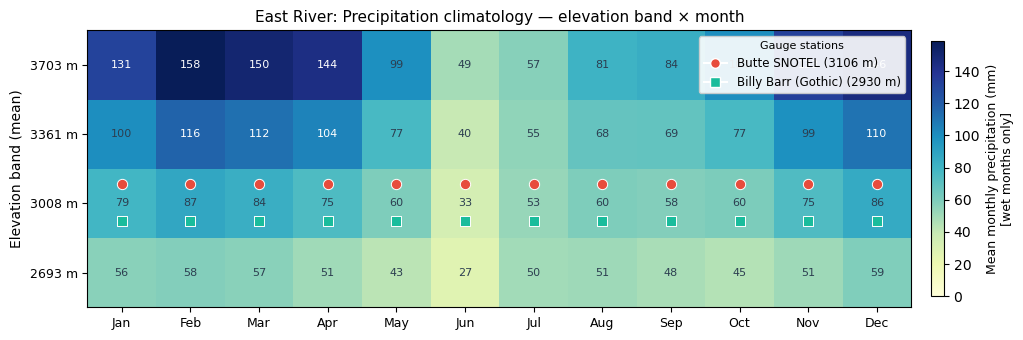

In [5]:
# ── Elevation band × month heatmap ────────────────────────────────────────────
from matplotlib.lines import Line2D

elev_classes = sorted(hru_meta['elevClass'].unique())   # 1..4, low→high
band_info = (
    hru_meta.reset_index()
    .groupby('elevClass')
    .agg(hru_ids=('HRU_ID', list), elev_mean=('elev_mean', 'mean'))
    .sort_index(ascending=True)   # low elevation first
)

band_df = pd.DataFrame(index=forcing_df.index)
for ec, row in band_info.iterrows():
    cols = [h for h in row['hru_ids'] if h in forcing_df.columns]
    band_df[ec] = forcing_df[cols].mean(axis=1)

band_clim = band_df.where(band_df > 1.0).groupby(level='month').mean()   # (12, 4)

elev_bands   = band_clim.columns.tolist()
band_elevs   = np.array([band_info.loc[ec, 'elev_mean'] for ec in elev_bands])
heatmap      = band_clim[elev_bands].T.values   # (4, 12) low→high
n_bands      = len(elev_bands)

fig, ax = plt.subplots(figsize=(11, 3.5))

vmax = np.nanmax(heatmap)
im = ax.pcolormesh(
    np.arange(0.5, 13.5),
    np.arange(n_bands + 1),
    heatmap,
    cmap='YlGnBu', vmin=0, vmax=vmax, shading='flat',
)
cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.92)
cb.set_label('Mean monthly precipitation (mm)\n[wet months only]', fontsize=9)

for i in range(n_bands):
    for j, m in enumerate(range(1, 13)):
        val = heatmap[i, j]
        if not np.isnan(val):
            txt_color = 'white' if val > vmax * 0.65 else '#2c3e50'
            ax.text(m, i + 0.5, f'{val:.0f}', ha='center', va='center',
                    fontsize=8, color=txt_color, fontweight='500')

ax.set_yticks(np.arange(n_bands) + 0.5)
ax.set_yticklabels([f'{e:.0f} m' for e in band_elevs], fontsize=9)
ax.set_ylabel('Elevation band (mean)', fontsize=10)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontsize=9)
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0, n_bands)

# Station overlay
STN_COLORS_HM  = {'Butte SNOTEL': '#e74c3c', 'Billy Barr (Gothic)': '#1abc9c'}
STN_MARKS_HM   = {'Butte SNOTEL': 'o', 'Billy Barr (Gothic)': 's'}
for name, clim in obs_clim.items():
    stn_elev = STATIONS[name][1]
    y_pos = np.interp(stn_elev, band_elevs, np.arange(n_bands) + 0.5,
                      left=0.3, right=n_bands - 0.3)
    xs = [m for m in range(1, 13) if not np.isnan(clim.get(m, np.nan))]
    ax.scatter(xs, [y_pos]*len(xs), s=55, color=STN_COLORS_HM[name], zorder=6,
               marker=STN_MARKS_HM[name], edgecolors='white', linewidths=0.7)

legend_handles = [
    Line2D([0],[0], marker=STN_MARKS_HM[n], color='w',
           markerfacecolor=STN_COLORS_HM[n], markersize=7,
           markeredgecolor='white', label=f'{n} ({STATIONS[n][1]} m)')
    for n in obs_clim
]
ax.legend(handles=legend_handles, fontsize=8.5, loc='upper right',
          framealpha=0.9, title='Gauge stations', title_fontsize=8)

ax.set_title('East River: Precipitation climatology — elevation band × month', fontsize=11)
fig.tight_layout()
plt.show()

ASO flights selected (earliest per WY = peak SWE):
  WY2018: 2018-03-31 — ASO_50M_SWE_USCOGE_20180331.tif
  WY2019: 2019-04-07 — ASO_50M_SWE_USCOGE_20190407.tif
  WY2022: 2022-04-21 — ASO_Gunnison_EastRiver_20220421.tif
  WY2023: 2023-04-01 — ASO_EastRiver_20230401.tif
  WY2024: 2024-04-03 — ASO_EastRiver_20240403.tif
  WY2025: 2025-04-07 — ASO_EastRiver_20250407.tif
  WY2026: 2026-03-18 — ASO_EastRiver_20260318.tif


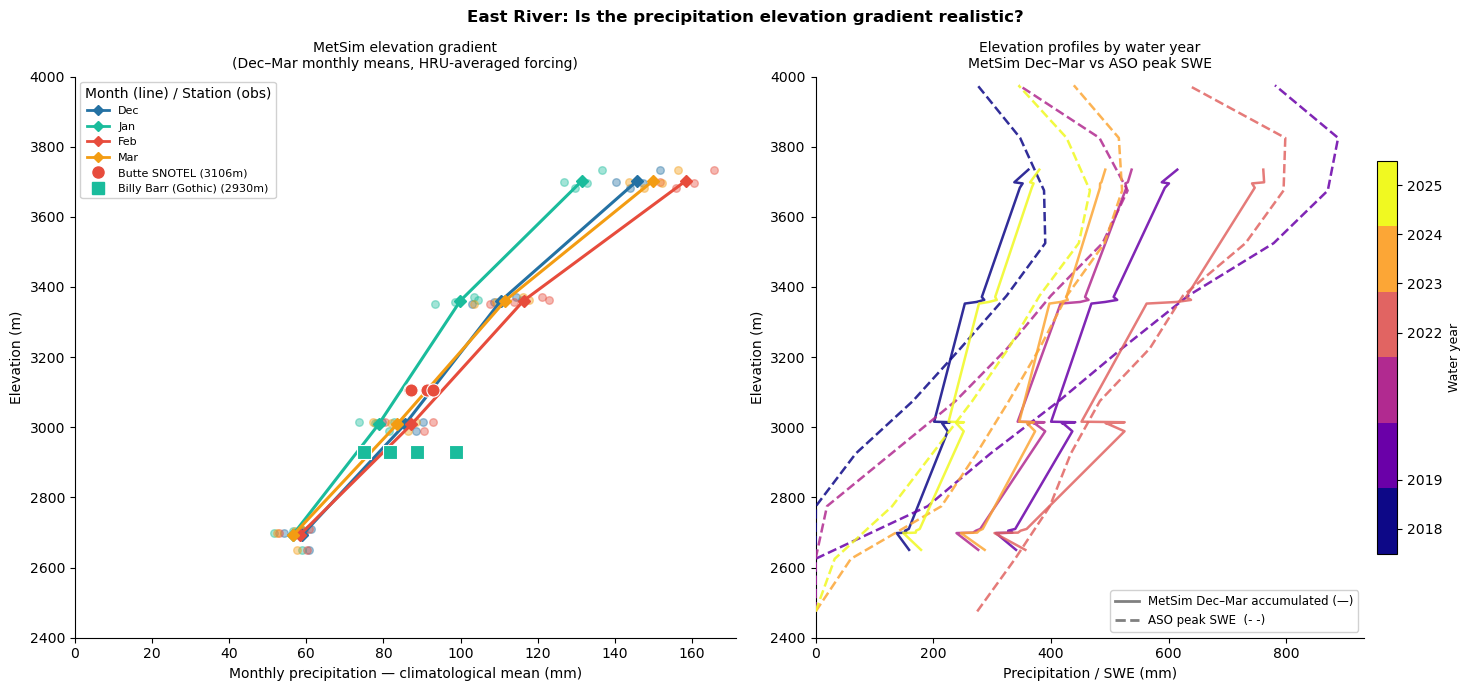

In [6]:
# ── MetSim elevation gradient + ASO SWE comparison ───────────────────────────
#
# Panel 1: Dec–Mar monthly means by HRU elevation (dots = individual HRUs,
#          diamonds = elevation band mean)
# Panel 2: Per-year Dec–Mar MetSim accumulation vs ASO peak SWE by elevation

import re
import rioxarray as rxr
from pathlib import Path

MO_COLORS = {12: '#2471a3', 1: '#1abc9c', 2: '#e74c3c', 3: '#f39c12'}
MO_LABELS = {12: 'Dec', 1: 'Jan', 2: 'Feb', 3: 'Mar'}
ELEV_BINS    = np.arange(2400, 4100, 150)
ELEV_CENTERS = (ELEV_BINS[:-1] + ELEV_BINS[1:]) / 2

# Band metadata
band_elev_m = hru_meta.groupby('elevClass')['elev_mean'].mean().sort_index()

# ── 1. MetSim per-year Dec–Mar accumulation per HRU ──────────────────────────
wy_metsim_prof = {}
for wy in range(1982, 2027):
    keys  = [(wy-1, 12), (wy, 1), (wy, 2), (wy, 3)]
    avail = []
    for k in keys:
        try:
            avail.append(forcing_df.loc[k])
        except KeyError:
            pass
    if len(avail) == 4:
        wy_metsim_prof[wy] = pd.concat(avail, axis=1).sum(axis=1)

# ── 2. ASO peak SWE — binned by elevation ────────────────────────────────────
def bin_by_elev(values, elev_arr, valid_mask):
    result = []
    for lo, hi in zip(ELEV_BINS[:-1], ELEV_BINS[1:]):
        in_bin = valid_mask & (elev_arr >= lo) & (elev_arr < hi)
        v = values[in_bin]
        result.append(np.nanmedian(v) if np.any(in_bin) else np.nan)
    return np.array(result)

aso_files = sorted(Path(ASO_DIR).glob('*.tif'))
wy_flights = {}
for f in aso_files:
    m = re.search(r'\d{8}', f.name)
    if not m:
        continue
    d  = pd.to_datetime(m.group(), format='%Y%m%d')
    wy = d.year   # flights Jan–Jun → calendar year == WY
    if wy not in wy_flights or d < wy_flights[wy][0]:
        wy_flights[wy] = (d, f)

print('ASO flights selected (earliest per WY = peak SWE):')
for wy, (d, f) in sorted(wy_flights.items()):
    print(f'  WY{wy}: {d.date()} — {f.name}')

dem_utm = rxr.open_rasterio(DEM_PATH, masked=True).rio.reproject('EPSG:32613')  # UTM zone 13N for Colorado

wy_swe_prof = {}
for wy, (d_flight, f_aso) in sorted(wy_flights.items()):
    aso     = rxr.open_rasterio(f_aso, masked=True).squeeze()
    dem_m   = dem_utm.rio.reproject_match(aso)
    elev_px = dem_m.values.ravel()
    swe_px  = aso.values.ravel() * 1000.0   # m → mm
    valid   = ~np.isnan(elev_px) & ~np.isnan(swe_px) & (swe_px >= 0)
    wy_swe_prof[wy] = bin_by_elev(swe_px, elev_px, valid)

# ── 3. Dec–Mar climatological MetSim band mean ───────────────────────────────
band_clim_mo = {}   # elevClass → Series indexed by month
for ec in elev_classes:
    hrus = hru_meta[hru_meta['elevClass'] == ec].index.tolist()
    cols = [h for h in hrus if h in hru_clim.columns]
    band_clim_mo[ec] = hru_clim[cols].mean(axis=1)

# ── 4. Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Panel 1 — Monthly gradient
ax1 = axes[0]
STN_COLORS_ = {'Butte SNOTEL': '#e74c3c', 'Billy Barr (Gothic)': '#1abc9c'}
STN_MARKS_  = {'Butte SNOTEL': 'o', 'Billy Barr (Gothic)': 's'}

for mo in (12, 1, 2, 3):
    hru_vals  = hru_clim.loc[mo]
    hru_elevs_s = hru_meta.loc[hru_vals.index, 'elev_mean']
    valid = ~hru_vals.isna()
    ax1.scatter(hru_vals[valid].values, hru_elevs_s[valid].values,
                color=MO_COLORS[mo], alpha=0.4, s=30, zorder=2)

    band_xs = [band_clim_mo[ec].loc[mo] if mo in band_clim_mo[ec].index else np.nan
               for ec in sorted(elev_classes)]
    band_ys = [band_elev_m[ec] for ec in sorted(elev_classes)]
    mask = [not np.isnan(x) for x in band_xs]
    ax1.plot(
        [x for x, m in zip(band_xs, mask) if m],
        [y for y, m in zip(band_ys, mask) if m],
        color=MO_COLORS[mo], lw=2.2, marker='D', ms=6,
        label=MO_LABELS[mo], zorder=4
    )

for name, clim in obs_clim.items():
    elev = STATIONS[name][1]
    for mo in (12, 1, 2, 3):
        val = clim.get(mo, np.nan)
        if not np.isnan(val):
            ax1.scatter(val, elev, color=STN_COLORS_[name],
                        marker=STN_MARKS_[name], s=90, zorder=7,
                        edgecolors='white', lw=0.8)

legend_hdl = [
    Line2D([0],[0], color=MO_COLORS[mo], lw=2, marker='D', ms=5, label=MO_LABELS[mo])
    for mo in (12, 1, 2, 3)
]
for name in obs_clim:
    legend_hdl.append(
        Line2D([0],[0], color=STN_COLORS_[name], ls='', marker=STN_MARKS_[name],
               ms=8, label=f'{name} ({STATIONS[name][1]}m)')
    )
ax1.legend(handles=legend_hdl, fontsize=8, loc='upper left', framealpha=0.9,
           title='Month (line) / Station (obs)')
ax1.set_xlabel('Monthly precipitation — climatological mean (mm)', fontsize=10)
ax1.set_ylabel('Elevation (m)', fontsize=10)
ax1.set_title('MetSim elevation gradient\n(Dec–Mar monthly means, HRU-averaged forcing)', fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_ylim(2400, 4000)
ax1.set_xlim(left=0)

# Panel 2 — Per-year accumulation vs ASO
ax2 = axes[1]
years = sorted(set(wy_metsim_prof) & set(wy_swe_prof))
cmap_yr = plt.get_cmap('plasma', len(years))

for i, wy in enumerate(years):
    color = cmap_yr(i)
    metsim_ser = wy_metsim_prof[wy]
    hru_e = hru_meta['elev_mean'].values
    hru_v = metsim_ser.reindex(hru_meta.index).values
    order = np.argsort(hru_e)
    ax2.plot(hru_v[order], hru_e[order],
             color=color, lw=1.8, ls='-', alpha=0.85, zorder=3)

    swe    = wy_swe_prof[wy]
    valid_s = ~np.isnan(swe)
    ax2.plot(swe[valid_s], ELEV_CENTERS[valid_s],
             color=color, lw=1.8, ls='--', alpha=0.85, zorder=3)

legend_style = [
    Line2D([0],[0], color='grey', ls='-',  lw=2, label='MetSim Dec–Mar accumulated (—)'),
    Line2D([0],[0], color='grey', ls='--', lw=2, label='ASO peak SWE  (- -)'),
]
ax2.legend(handles=legend_style, fontsize=8.5, loc='lower right', framealpha=0.9)

sm2 = plt.cm.ScalarMappable(
    cmap=cmap_yr,
    norm=mcolors.Normalize(vmin=years[0]-0.5, vmax=years[-1]+0.5)
)
sm2.set_array([])
cb2 = fig.colorbar(sm2, ax=ax2, shrink=0.7, pad=0.02)
cb2.set_ticks(years[::max(1, len(years)//5)])
cb2.set_label('Water year', fontsize=9)

ax2.set_xlabel('Precipitation / SWE (mm)', fontsize=10)
ax2.set_ylabel('Elevation (m)', fontsize=10)
ax2.set_title('Elevation profiles by water year\nMetSim Dec–Mar vs ASO peak SWE', fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_ylim(2400, 4000)
ax2.set_xlim(left=0)

fig.suptitle('East River: Is the precipitation elevation gradient realistic?', fontsize=12, fontweight='600')
fig.tight_layout()
plt.show()

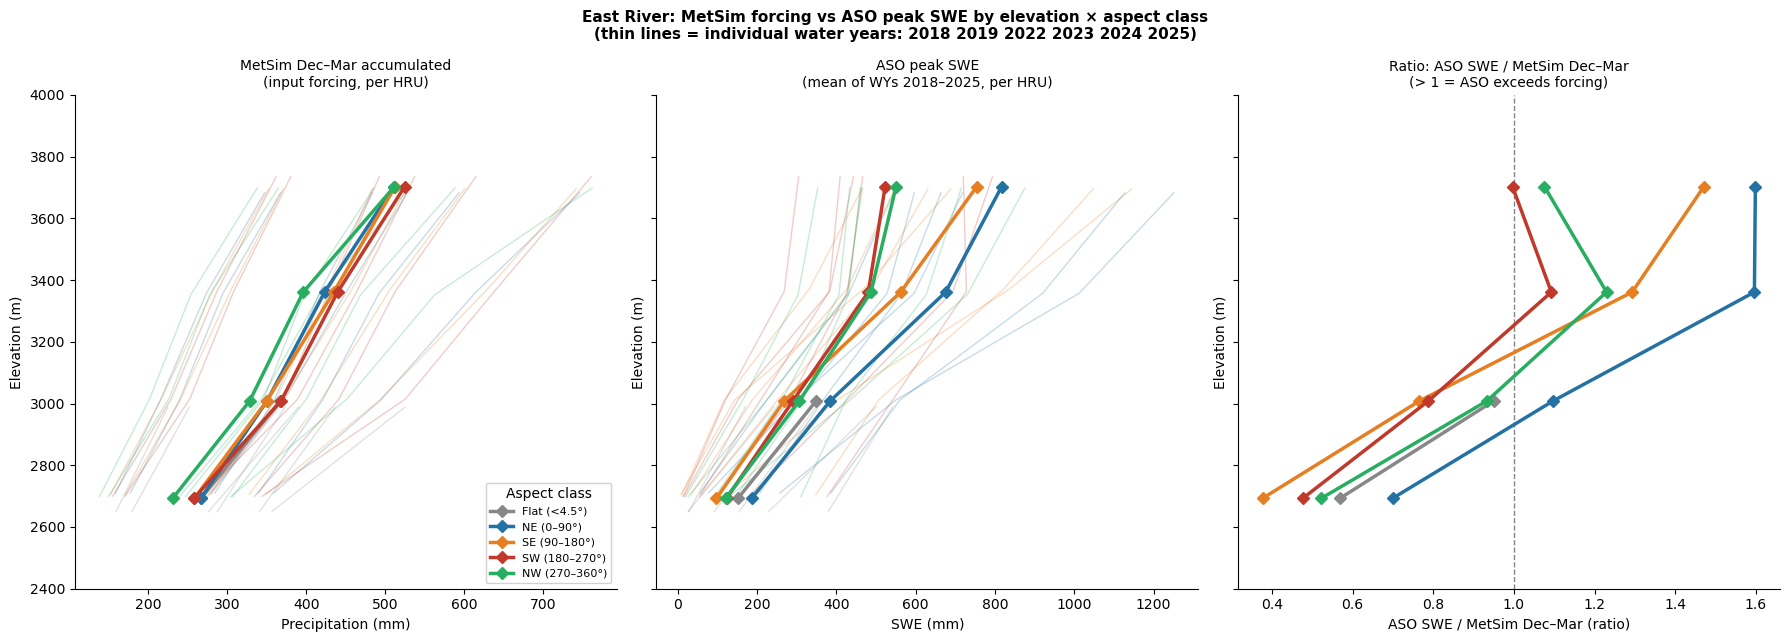

In [7]:
# ── ASO SWE vs MetSim by elevation × aspect class ────────────────────────────
#
# Rasterizes HRU polygons onto each ASO grid, computes per-HRU mean SWE,
# then plots MetSim Dec–Mar forcing vs ASO SWE by aspect class.

import rasterio
from rasterio.features import rasterize

SHP_UTM = gpd.read_file(SHP_PATH).to_crs(epsg=32613).sort_values('HRU_ID').reset_index(drop=True)
shapes  = list(zip(SHP_UTM.geometry, SHP_UTM['HRU_ID'].astype(int)))

ac_vals = SHP_UTM[ac_col].values.astype(int)
ec_vals = SHP_UTM['elevClass'].values.astype(int)
em_vals = SHP_UTM['elev_mean'].values
hru_areas = SHP_UTM.geometry.area.values   # m²

aspect_classes = sorted(np.unique(ac_vals))
band_elev      = {ec: em_vals[ec_vals == ec].mean() for ec in elev_bands}

ASPECT_LABELS = {0: 'Flat (<4.5°)', 1: 'NE (0–90°)', 2: 'SE (90–180°)',
                 3: 'SW (180–270°)', 4: 'NW (270–360°)'}
ASPECT_COLORS = {0: '#888888', 1: '#2471a3', 2: '#e67e22', 3: '#c0392b', 4: '#27ae60'}

# ── Per-HRU mean ASO SWE ─────────────────────────────────────────────────────
wy_hru_swe = {}
for wy, (d_flight, f_aso) in sorted(wy_flights.items()):
    aso     = rxr.open_rasterio(f_aso, masked=True).squeeze()
    hru_grid = rasterize(
        shapes, out_shape=aso.shape,
        transform=aso.rio.transform(), fill=0, dtype='int32'
    )
    swe_px = aso.values * 1000.0   # m → mm
    hru_swe = np.full(len(SHP_UTM), np.nan)
    for i, hru_id in enumerate(SHP_UTM['HRU_ID'].astype(int)):
        mask = (hru_grid == hru_id)
        vals = swe_px[mask]
        valid = vals[~np.isnan(vals) & (vals >= 0)]
        if len(valid) > 0:
            hru_swe[i] = np.nanmean(valid)
    wy_hru_swe[wy] = hru_swe

# ── Accumulate mean across years ──────────────────────────────────────────────
years_both = sorted(set(wy_hru_swe) & set(wy_metsim_prof))

ms_by_ac  = {ac: {ec: [] for ec in elev_bands} for ac in aspect_classes}
swe_by_ac = {ac: {ec: [] for ec in elev_bands} for ac in aspect_classes}

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)
ax_ms, ax_aso, ax_rat = axes
ALPHA_YR = 0.25
LW_MEAN  = 2.5

for wy in years_both:
    metsim_ser = wy_metsim_prof[wy]
    for i, hru_id in enumerate(SHP_UTM['HRU_ID'].astype(int)):
        ac = ac_vals[i]; ec = ec_vals[i]
        ms_val  = metsim_ser.get(hru_id, np.nan)
        swe_val = wy_hru_swe[wy][i]
        if not np.isnan(ms_val):  ms_by_ac[ac][ec].append(ms_val)
        if not np.isnan(swe_val): swe_by_ac[ac][ec].append(swe_val)

    for ac in aspect_classes:
        color  = ASPECT_COLORS[ac]
        hrus_ac = [i for i, a in enumerate(ac_vals) if a == ac]
        ms_e  = [em_vals[i] for i in hrus_ac]
        ms_v  = [metsim_ser.get(SHP_UTM['HRU_ID'].iloc[i], np.nan) for i in hrus_ac]
        swe_e = [em_vals[i] for i in hrus_ac]
        swe_v = [wy_hru_swe[wy][i] for i in hrus_ac]
        order_ms  = np.argsort(ms_e)
        order_swe = np.argsort(swe_e)
        ax_ms.plot([ms_v[j] for j in order_ms],  [ms_e[j] for j in order_ms],
                   color=color, alpha=ALPHA_YR, lw=1.0, zorder=2)
        ax_aso.plot([swe_v[j] for j in order_swe], [swe_e[j] for j in order_swe],
                   color=color, alpha=ALPHA_YR, lw=1.0, zorder=2)

for ac in aspect_classes:
    color = ASPECT_COLORS[ac]
    label = ASPECT_LABELS[ac]
    ms_mean_x, ms_mean_y   = [], []
    swe_mean_x, swe_mean_y = [], []
    rat_x, rat_y           = [], []
    for ec in elev_bands:
        ey     = band_elev[ec]
        ms_m   = np.nanmean(ms_by_ac[ac][ec])  if ms_by_ac[ac][ec]  else np.nan
        swe_m  = np.nanmean(swe_by_ac[ac][ec]) if swe_by_ac[ac][ec] else np.nan
        ms_mean_x.append(ms_m);   ms_mean_y.append(ey)
        swe_mean_x.append(swe_m); swe_mean_y.append(ey)
        rat_x.append(swe_m / ms_m if (not np.isnan(ms_m) and ms_m > 0) else np.nan)
        rat_y.append(ey)
    ax_ms.plot(ms_mean_x,  ms_mean_y,  color=color, lw=LW_MEAN, marker='D', ms=6, label=label, zorder=5)
    ax_aso.plot(swe_mean_x, swe_mean_y, color=color, lw=LW_MEAN, marker='D', ms=6, label=label, zorder=5)
    ax_rat.plot(rat_x, rat_y,           color=color, lw=LW_MEAN, marker='D', ms=6, label=label, zorder=5)

ax_rat.axvline(1.0, color='#333333', lw=1.0, ls='--', alpha=0.6, label='ASO = MetSim')

for ax, title in zip(axes, [
        'MetSim Dec–Mar accumulated\n(input forcing, per HRU)',
        f'ASO peak SWE\n(mean of WYs {min(years_both)}–{max(years_both)}, per HRU)',
        'Ratio: ASO SWE / MetSim Dec–Mar\n(> 1 = ASO exceeds forcing)'
]):
    ax.set_ylabel('Elevation (m)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(2400, 4000)

ax_ms.set_xlabel('Precipitation (mm)', fontsize=10)
ax_aso.set_xlabel('SWE (mm)', fontsize=10)
ax_rat.set_xlabel('ASO SWE / MetSim Dec–Mar (ratio)', fontsize=10)
handles, labels_ = ax_ms.get_legend_handles_labels()
ax_ms.legend(handles, labels_, fontsize=8, loc='lower right', framealpha=0.9, title='Aspect class')

fig.suptitle(
    f'East River: MetSim forcing vs ASO peak SWE by elevation × aspect class\n'
    f'(thin lines = individual water years: {" ".join(str(y) for y in years_both)})',
    fontsize=11, fontweight='600'
)
fig.tight_layout()
plt.show()

Area-weighted mean of f(e) = 1.00000  (1.0 = perfect conservation)
Basin-mean MetSim Dec–Mar  = 373.2 mm
Basin-mean ASO SWE         = 392.6 mm

 Band   Elev (m)    SWE (mm)     f(e)   Area (km²)
    1       2693       135.6    0.345        152.4
    2       3008       319.3    0.813        278.1
    3       3361       551.2    1.404        233.9
    4       3703       660.8    1.683         83.8


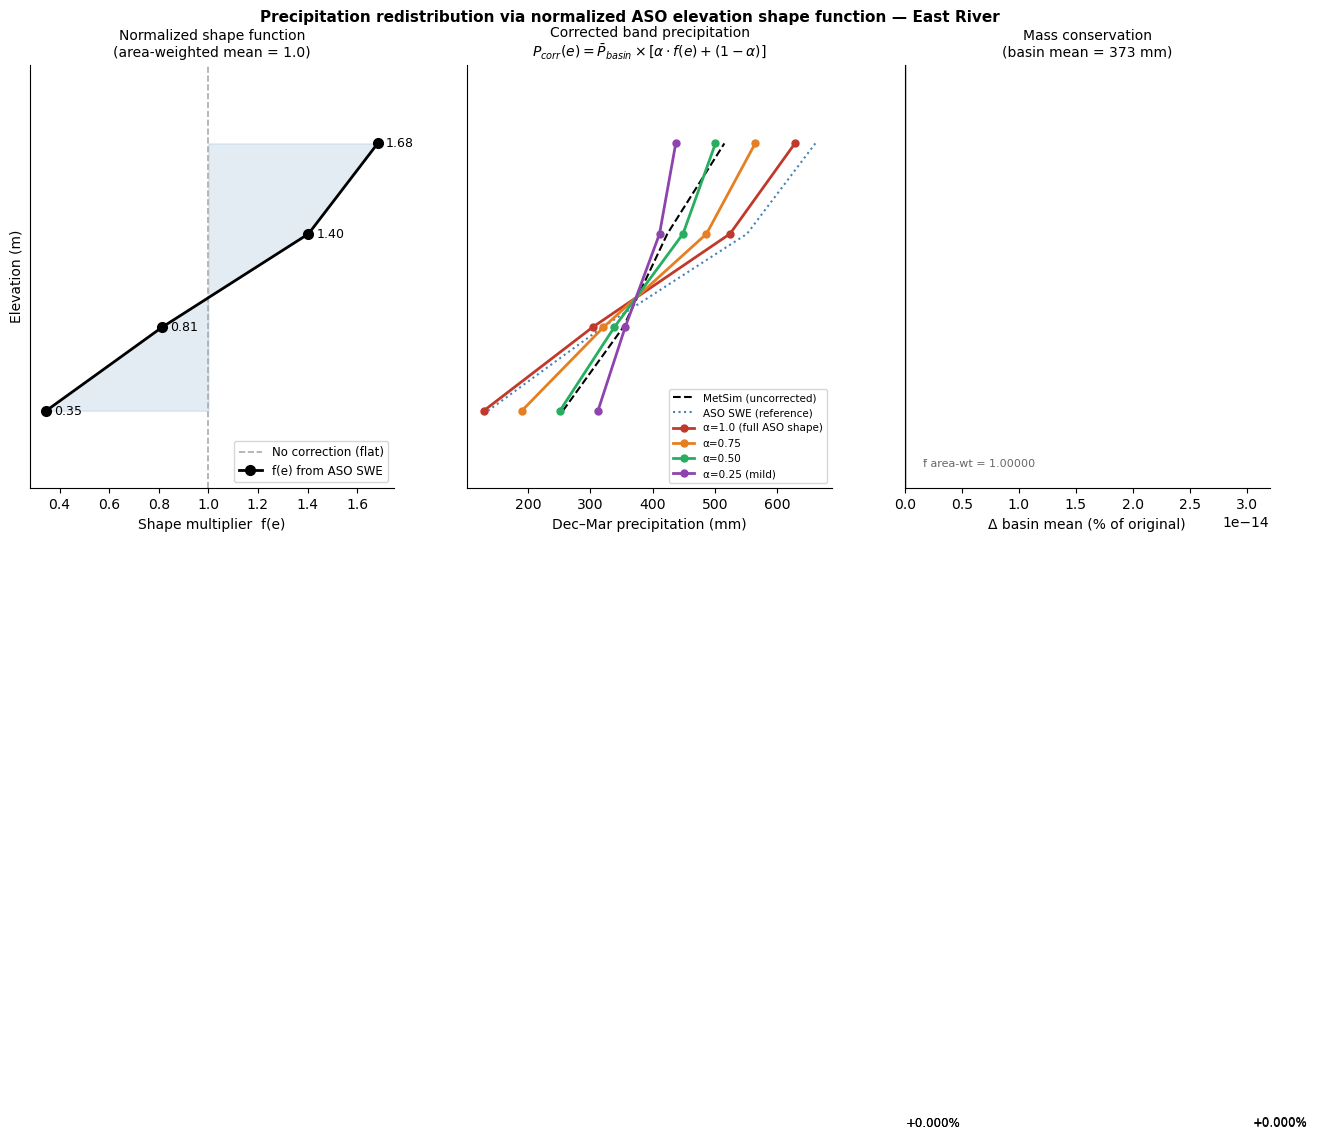

In [8]:
# ── Normalized ASO elevation shape function ────────────────────────────────────
#
# f(e) = mean_ASO_SWE(elevBand) / area_weighted_basin_mean_SWE
# Blending: f_blend(e, α) = α × f(e) + (1–α)
# Area-weighted mean of f = 1.0 → basin-total precipitation conserved.

# ── Band-mean ASO SWE (collapse aspect + years) ───────────────────────────────
band_swe_mean = {}
for ec in elev_bands:
    vals = [wy_hru_swe[wy][i]
            for wy in years_both
            for i, eec in enumerate(ec_vals)
            if eec == ec and not np.isnan(wy_hru_swe[wy][i]) and wy_hru_swe[wy][i] >= 0]
    band_swe_mean[ec] = np.nanmean(vals) if vals else np.nan

band_area = {ec: hru_areas[ec_vals == ec].sum() for ec in elev_bands}
total_area = sum(band_area.values())

mu_swe = sum(band_swe_mean[ec] * band_area[ec] / total_area
             for ec in elev_bands if not np.isnan(band_swe_mean.get(ec, np.nan)))

shape_f = {ec: band_swe_mean[ec] / mu_swe
           if not np.isnan(band_swe_mean.get(ec, np.nan)) else np.nan
           for ec in elev_bands}
f_wt_mean = sum(shape_f[ec] * band_area[ec] / total_area
                for ec in elev_bands if not np.isnan(shape_f[ec]))

# ── MetSim basin-mean Dec–Mar ─────────────────────────────────────────────────
band_ms_mean = {}
for ec in elev_bands:
    vals = [wy_metsim_prof[wy].get(SHP_UTM['HRU_ID'].iloc[i], np.nan)
            for wy in years_both
            for i, eec in enumerate(ec_vals) if eec == ec]
    band_ms_mean[ec] = np.nanmean([v for v in vals if not np.isnan(v)])

ms_basin_mean = sum(band_ms_mean[ec] * band_area[ec] / total_area
                    for ec in elev_bands if not np.isnan(band_ms_mean.get(ec, np.nan)))

print(f'Area-weighted mean of f(e) = {f_wt_mean:.5f}  (1.0 = perfect conservation)')
print(f'Basin-mean MetSim Dec–Mar  = {ms_basin_mean:.1f} mm')
print(f'Basin-mean ASO SWE         = {mu_swe:.1f} mm\n')
print(f'{"Band":>5}  {"Elev (m)":>9}  {"SWE (mm)":>10}  {"f(e)":>7}  {"Area (km²)":>11}')
for ec in elev_bands:
    print(f'{ec:>5}  {band_elev[ec]:>9.0f}  {band_swe_mean[ec]:>10.1f}  '
          f'{shape_f[ec]:>7.3f}  {band_area[ec]/1e6:>11.1f}')

# ── Blending for α ∈ {1.0, 0.75, 0.5, 0.25} ──────────────────────────────────
ALPHAS       = [1.0, 0.75, 0.5, 0.25]
ALPHA_COLORS = {1.0: '#c0392b', 0.75: '#e67e22', 0.5: '#27ae60', 0.25: '#8e44ad'}
ALPHA_LABELS = {1.0: 'α=1.0 (full ASO shape)',
                0.75: 'α=0.75',
                0.5:  'α=0.50',
                0.25: 'α=0.25 (mild)'}

band_elevs_list = [band_elev[ec] for ec in elev_bands]
f_list          = [shape_f[ec]   for ec in elev_bands]
ms_list         = [band_ms_mean[ec] for ec in elev_bands]
swe_list        = [band_swe_mean[ec] for ec in elev_bands]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
ax_f, ax_p, ax_chk = axes

# Panel 1 — shape function
ax_f.axvline(1.0, color='#aaaaaa', lw=1.2, ls='--', label='No correction (flat)')
ax_f.plot(f_list, band_elevs_list, 'ko-', lw=2.0, ms=7, label='f(e) from ASO SWE')
ax_f.fill_betweenx(band_elevs_list, [1.0]*len(elev_bands), f_list,
                   alpha=0.15, color='steelblue')
for ec, ey, fv in zip(elev_bands, band_elevs_list, f_list):
    ax_f.annotate(f'{fv:.2f}', xy=(fv, ey), xytext=(6, 0),
                  textcoords='offset points', fontsize=9, va='center')
ax_f.set_xlabel('Shape multiplier  f(e)', fontsize=10)
ax_f.set_ylabel('Elevation (m)', fontsize=10)
ax_f.set_title('Normalized shape function\n(area-weighted mean = 1.0)', fontsize=10)
ax_f.legend(fontsize=8.5, loc='lower right')
ax_f.spines[['top', 'right']].set_visible(False)
ax_f.set_ylim(2400, 4000)

# Panel 2 — corrected precipitation
ax_p.plot(ms_list,  band_elevs_list, 'k--', lw=1.5, label='MetSim (uncorrected)', zorder=2)
ax_p.plot(swe_list, band_elevs_list, color='steelblue', ls=':', lw=1.5,
          label='ASO SWE (reference)', zorder=2)
for alpha in ALPHAS:
    P_corr = [ms_basin_mean * (alpha * fv + (1 - alpha)) for fv in f_list]
    ax_p.plot(P_corr, band_elevs_list, color=ALPHA_COLORS[alpha],
              lw=2.0, marker='o', ms=5, label=ALPHA_LABELS[alpha], zorder=3)
ax_p.set_xlabel('Dec–Mar precipitation (mm)', fontsize=10)
ax_p.set_title('Corrected band precipitation\n'
               r'$P_{corr}(e) = \bar{P}_{basin} \times [\alpha \cdot f(e) + (1-\alpha)]$',
               fontsize=10)
ax_p.legend(fontsize=7.5, loc='lower right')
ax_p.spines[['top', 'right']].set_visible(False)

# Panel 3 — mass conservation check
pct_errors = []
for alpha in ALPHAS:
    total = sum(ms_basin_mean * (alpha * shape_f[ec] + (1 - alpha)) * band_area[ec]
                for ec in elev_bands if not np.isnan(shape_f[ec])) / total_area
    pct_errors.append((total - ms_basin_mean) / ms_basin_mean * 100)

bars = ax_chk.barh([ALPHA_LABELS[a] for a in ALPHAS], pct_errors,
                   color=[ALPHA_COLORS[a] for a in ALPHAS], alpha=0.82)
ax_chk.axvline(0, color='black', lw=1.0)
for bar, pct in zip(bars, pct_errors):
    ax_chk.text(pct + 0.002 * max(abs(p) for p in pct_errors),
                bar.get_y() + bar.get_height() / 2,
                f'{pct:+.3f}%', va='center', fontsize=8.5)
ax_chk.set_xlabel('Δ basin mean (% of original)', fontsize=10)
ax_chk.set_title(f'Mass conservation\n(basin mean = {ms_basin_mean:.0f} mm)', fontsize=10)
ax_chk.text(0.05, 0.05, f'f̄ area-wt = {f_wt_mean:.5f}',
            transform=ax_chk.transAxes, fontsize=8, color='#666666')
ax_chk.spines[['top', 'right']].set_visible(False)

fig.suptitle('Precipitation redistribution via normalized ASO elevation shape function — East River',
             fontsize=11, fontweight='600')
fig.tight_layout()
plt.show()